<a href="https://colab.research.google.com/github/inteliun/PRESENTACIONES/blob/main/predicci%C3%B3n_diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset cargado correctamente.
Filas: 768
Columnas: 9


,Embarazos,Glucosa,PresionArterial,GrosorPiel,Insulina,IMC,PedigreeDiabetes,Edad,Resultado
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Distribución de resultados:
Resultado
0    500
1    268
Name: count, dtype: int64

Porcentaje de casos:
Resultado
0    65.104167
1    34.895833
Name: proportion, dtype: float64

Valores ausentes después del tratamiento:


,0
Embarazos,0
Glucosa,5
PresionArterial,35
GrosorPiel,227
Insulina,374
IMC,11
PedigreeDiabetes,0
Edad,0
Resultado,0



✅ Modelo entrenado correctamente.

📊 EVALUACIÓN DEL MODELO
Accuracy : 74.68%
Precision: 65.96%
Recall   : 57.41%
F1-Score : 61.39%
ROC-AUC  : 0.825

Reporte de clasificación:
              precision    recall  f1-score   support

Sin diabetes       0.79      0.84      0.81       100
    Diabetes       0.66      0.57      0.61        54

    accuracy                           0.75       154
   macro avg       0.72      0.71      0.71       154
weighted avg       0.74      0.75      0.74       154



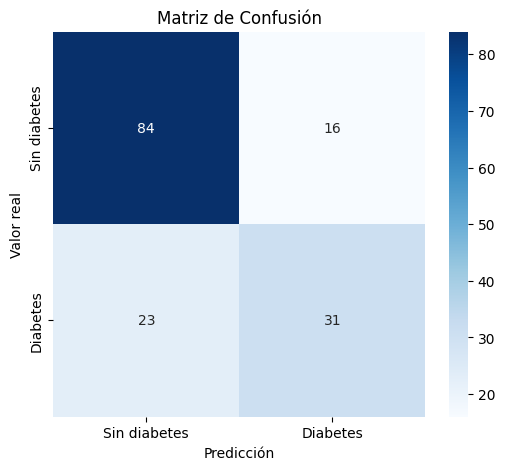


📌 Importancia de variables:


,Variable,Importancia
1,Glucosa,0.273778
5,IMC,0.190169
7,Edad,0.127875
6,PedigreeDiabetes,0.113937
4,Insulina,0.093652
3,GrosorPiel,0.072915
2,PresionArterial,0.065241
0,Embarazos,0.062433


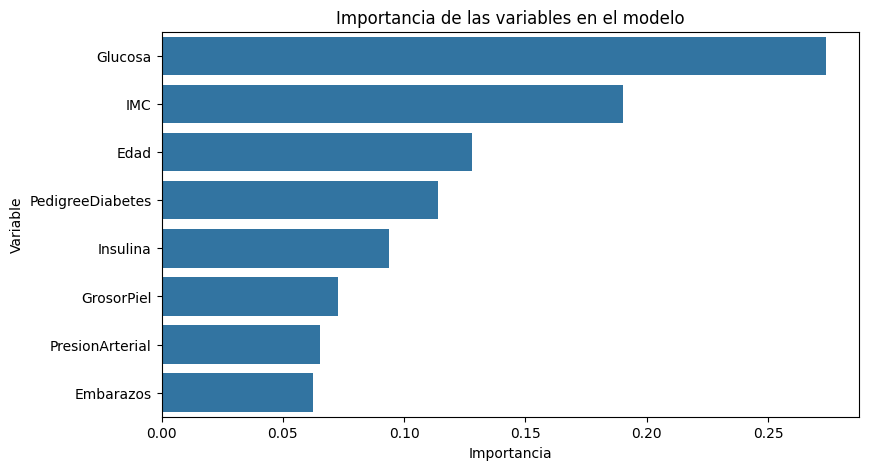

🩺 RESULTADO DE LA EVALUACIÓN

Probabilidad estimada: 48.8%

🟡 NIVEL ESTIMADO: MODERADO

                El modelo estima una probabilidad intermedia.
                Sería recomendable valorar estos resultados junto
                con otros factores clínicos.
                

-------------------------------------------------------
📌 Clasificación del modelo: NO DIABETES
-------------------------------------------------------

⚠️ IMPORTANTE

Esta herramienta es únicamente educativa y experimental.
La predicción procede de un modelo estadístico entrenado con
un dataset histórico y no sustituye una evaluación médica,
una analítica de laboratorio ni el diagnóstico de un profesional
sanitario.



In [2]:
# ============================================================
# 🩺 PREDICTOR DE DIABETES - RANDOM FOREST
# Dataset: Pima Indians Diabetes
# Compatible con Google Colab / Jupyter Notebook
# ============================================================

# ============================================================
# 1. INSTALACIÓN E IMPORTACIÓN
# ============================================================

!pip install -q ipywidgets scikit-learn pandas matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import ipywidgets as widgets

from IPython.display import display, clear_output, HTML

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# ============================================================
# 2. CARGAR DATASET
# ============================================================

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columnas = [
    "Embarazos",
    "Glucosa",
    "PresionArterial",
    "GrosorPiel",
    "Insulina",
    "IMC",
    "PedigreeDiabetes",
    "Edad",
    "Resultado"
]

df = pd.read_csv(url, names=columnas)

print("Dataset cargado correctamente.")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

display(df.head())

# ============================================================
# 3. ANÁLISIS INICIAL
# ============================================================

print("\nDistribución de resultados:")
print(df["Resultado"].value_counts())

print("\nPorcentaje de casos:")
print(df["Resultado"].value_counts(normalize=True) * 100)

# ============================================================
# 4. TRATAMIENTO DE VALORES AUSENTES
# ============================================================

# En este dataset, determinados valores 0 no son fisiológicamente
# razonables y se consideran valores ausentes.

columnas_cero = [
    "Glucosa",
    "PresionArterial",
    "GrosorPiel",
    "Insulina",
    "IMC"
]

df_modelo = df.copy()

for columna in columnas_cero:
    df_modelo[columna] = df_modelo[columna].replace(0, np.nan)

print("\nValores ausentes después del tratamiento:")
display(df_modelo.isnull().sum())

# ============================================================
# 5. SEPARAR VARIABLES Y OBJETIVO
# ============================================================

X = df_modelo.drop("Resultado", axis=1)
y = df_modelo["Resultado"]

# ============================================================
# 6. DIVISIÓN TRAIN / TEST
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ============================================================
# 7. IMPUTACIÓN DE VALORES AUSENTES
# ============================================================

imputer = SimpleImputer(strategy="median")

X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

# ============================================================
# 8. ENTRENAMIENTO DEL RANDOM FOREST
# ============================================================

modelo_base = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Calibramos las probabilidades para que predict_proba()
# sea más interpretable.
modelo = CalibratedClassifierCV(
    modelo_base,
    method="sigmoid",
    cv=5
)

modelo.fit(X_train_imp, y_train)

print("\n✅ Modelo entrenado correctamente.")

# ============================================================
# 9. EVALUACIÓN
# ============================================================

y_pred = modelo.predict(X_test_imp)
y_prob = modelo.predict_proba(X_test_imp)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_prob)

print("\n" + "=" * 55)
print("📊 EVALUACIÓN DEL MODELO")
print("=" * 55)

print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")
print(f"F1-Score : {f1 * 100:.2f}%")
print(f"ROC-AUC  : {auc:.3f}")

print("\nReporte de clasificación:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Sin diabetes", "Diabetes"],
    zero_division=0
))

# ============================================================
# 10. MATRIZ DE CONFUSIÓN
# ============================================================

matriz = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    matriz,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Sin diabetes", "Diabetes"],
    yticklabels=["Sin diabetes", "Diabetes"]
)

plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

# ============================================================
# 11. IMPORTANCIA DE LAS VARIABLES
# ============================================================

# Recuperamos el Random Forest entrenado dentro del calibrador.
rf = modelo.calibrated_classifiers_[0].estimator

importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": rf.feature_importances_
}).sort_values(
    "Importancia",
    ascending=False
)

print("\n📌 Importancia de variables:")
display(importancias)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=importancias,
    x="Importancia",
    y="Variable"
)

plt.title("Importancia de las variables en el modelo")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

# ============================================================
# 12. FUNCIÓN DE PREDICCIÓN
# ============================================================

def predecir_diabetes(
    embarazos,
    glucosa,
    presion,
    piel,
    insulina,
    imc,
    pedigree,
    edad
):

    paciente = pd.DataFrame([{
        "Embarazos": embarazos,
        "Glucosa": glucosa,
        "PresionArterial": presion,
        "GrosorPiel": piel,
        "Insulina": insulina,
        "IMC": imc,
        "PedigreeDiabetes": pedigree,
        "Edad": edad
    }])

    # Los ceros se consideran valores ausentes en las mismas
    # variables utilizadas durante el entrenamiento.
    for columna in columnas_cero:
        paciente[columna] = paciente[columna].replace(0, np.nan)

    paciente_imp = imputer.transform(paciente)

    prediccion = modelo.predict(paciente_imp)[0]

    probabilidad = modelo.predict_proba(paciente_imp)[0][1]

    return prediccion, probabilidad

# ============================================================
# 13. INTERFAZ GRÁFICA
# ============================================================

titulo = widgets.HTML("""
<div style="
    background: linear-gradient(135deg, #2563eb, #1d4ed8);
    color: white;
    padding: 20px;
    border-radius: 12px;
    margin-bottom: 15px;
">
    <h1 style="margin:0;">🩺 Evaluador de Riesgo de Diabetes</h1>
    <p style="margin-top:8px;">
        Modelo de Machine Learning basado en Random Forest
    </p>
</div>
""")

descripcion = widgets.HTML("""
<p>
Introduce los datos del paciente y pulsa
<b>Evaluar riesgo</b>.
</p>
<p style="color:#666;">
El resultado es una predicción estadística y no constituye un diagnóstico médico.
</p>
""")

# ============================================================
# 14. CAMPOS
# ============================================================

embarazos = widgets.IntSlider(
    value=2,
    min=0,
    max=17,
    step=1,
    description="Embarazos:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="500px")
)

glucosa = widgets.IntSlider(
    value=120,
    min=1,
    max=200,
    step=1,
    description="Glucosa:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="500px")
)

presion = widgets.IntSlider(
    value=70,
    min=1,
    max=140,
    step=1,
    description="Presión arterial:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="500px")
)

piel = widgets.IntSlider(
    value=20,
    min=1,
    max=100,
    step=1,
    description="Grosor de piel:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="500px")
)

insulina = widgets.IntSlider(
    value=80,
    min=1,
    max=850,
    step=1,
    description="Insulina:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="500px")
)

imc = widgets.FloatSlider(
    value=25.0,
    min=10,
    max=70,
    step=0.1,
    description="IMC:",
    readout_format=".1f",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="500px")
)

pedigree = widgets.FloatSlider(
    value=0.5,
    min=0.05,
    max=2.5,
    step=0.01,
    description="Pedigree diabetes:",
    readout_format=".2f",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="500px")
)

edad = widgets.IntSlider(
    value=30,
    min=18,
    max=100,
    step=1,
    description="Edad:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="500px")
)

# ============================================================
# 15. BOTÓN
# ============================================================

boton_predecir = widgets.Button(
    description="🔍 Evaluar riesgo",
    button_style="success",
    layout=widgets.Layout(
        width="500px",
        height="45px"
    )
)

salida = widgets.Output()

# ============================================================
# 16. FUNCIÓN DE LA INTERFAZ
# ============================================================

def evaluar_riesgo(boton):

    with salida:

        clear_output()

        try:

            prediccion, probabilidad = predecir_diabetes(
                embarazos.value,
                glucosa.value,
                presion.value,
                piel.value,
                insulina.value,
                imc.value,
                pedigree.value,
                edad.value
            )

            porcentaje = probabilidad * 100

            print("=" * 55)
            print("🩺 RESULTADO DE LA EVALUACIÓN")
            print("=" * 55)

            print(f"\nProbabilidad estimada: {porcentaje:.1f}%\n")

            # ------------------------------------------------
            # INTERPRETACIÓN
            # ------------------------------------------------

            if porcentaje < 30:

                print("🟢 NIVEL ESTIMADO: BAJO")

                mensaje = """
                El modelo estima una probabilidad relativamente baja
                de diabetes para los datos introducidos.
                """

            elif porcentaje < 60:

                print("🟡 NIVEL ESTIMADO: MODERADO")

                mensaje = """
                El modelo estima una probabilidad intermedia.
                Sería recomendable valorar estos resultados junto
                con otros factores clínicos.
                """

            else:

                print("🔴 NIVEL ESTIMADO: ELEVADO")

                mensaje = """
                El modelo estima una probabilidad elevada.
                Este resultado no confirma que exista diabetes.
                """

            print(mensaje)

            print("\n" + "-" * 55)

            if prediccion == 1:
                print("📌 Clasificación del modelo: DIABETES")
            else:
                print("📌 Clasificación del modelo: NO DIABETES")

            print("-" * 55)

            print("""
⚠️ IMPORTANTE

Esta herramienta es únicamente educativa y experimental.
La predicción procede de un modelo estadístico entrenado con
un dataset histórico y no sustituye una evaluación médica,
una analítica de laboratorio ni el diagnóstico de un profesional
sanitario.
""")

        except Exception as e:

            print("❌ Se produjo un error:")
            print(str(e))

# ============================================================
# 17. CONECTAR BOTÓN
# ============================================================

boton_predecir.on_click(evaluar_riesgo)

# ============================================================
# 18. MOSTRAR INTERFAZ
# ============================================================

interfaz = widgets.VBox([
    titulo,
    descripcion,

    widgets.HTML("<h3>Datos del paciente</h3>"),

    embarazos,
    glucosa,
    presion,
    piel,
    insulina,
    imc,
    pedigree,
    edad,

    widgets.HTML("<br>"),

    boton_predecir,

    widgets.HTML("<br>"),

    salida
])

display(interfaz)

# ============================================================
# FIN
# ============================================================